<a href="https://colab.research.google.com/github/elenasabbioni/SMARTbiomed_summerschool_2026/blob/main/LDSC_Practical_2_rg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astheeggeggs/testing_colab/blob/main/LDSC_Practical_2_rg.ipynb)

# 🧬 Practical 2: Genetic Correlation estimation using bivariate LD Score Regression (LDSC)

Welcome to the second practical! Here, we will learn how to estimate the genetic correlation ($r_g$) between two traits using bivariate LD Score Regression (LDSC).


---
## 🛠️ 1. Environment Setup & Data Download

This Colab notebook uses a **Python runtime**, but since the LDSC tools we are using are built in R, we will execute our code using **R cell magic** (`%%R`). We first need to load this extension, download the data, and install the required packages.

Packages used in this session:
* `data.table` & `dplyr`: For fast and efficient data manipulation.
* `remotes`: To install packages directly from GitHub.
* `corrplot`: For visualizing genetic correlation matrices.
* `GenomicSEM`: An R package that includes functions to run LDSC.


In [1]:
# System dependencies that are often useful for R package installation
!apt-get update -qq
!apt-get install -y -qq libcurl4-openssl-dev libxml2-dev libssl-dev


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libssl-dev_3.0.2-0ubuntu1.25_amd64.deb ...
Unpacking libssl-dev:amd64 (3.0.2-0ubuntu1.25) over (3.0.2-0ubuntu1.23) ...
Preparing to unpack .../libssl3_3.0.2-0ubuntu1.25_amd64.deb ...
Unpacking libssl3:amd64 (3.0.2-0ubuntu1.25) over (3.0.2-0ubuntu1.23) ...
Setting up libssl3:amd64 (3.0.2-0ubuntu1.25) ...
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libxml2-dev_2.9.13+dfsg-1ubuntu0.12_amd64.deb ...
Unpacking libxml2-dev:amd64 (2.9.13+dfsg-1ubuntu0.12) over (2.9.13+dfsg-1ubuntu0.11) ...
Preparing to unpack .../libxml2_2.9.13+dfsg-1ubuntu0.12_amd64.deb ...
Unpacking libxml2:amd64 (2.9.13+dfsg-1ubuntu0.12) over (2.9.13+dfsg-1ubuntu

In [2]:
# Load the R magic extension to run R code in this Python notebook
%load_ext rpy2.ipython


In [3]:
# Download the data for this practical
!gdown --folder https://drive.google.com/drive/folders/1DtztFjNBVYP6o72GCIwnUo7MyGjfURtx -O /content/LDSC_Practical_2
!tar -xzvf /content/LDSC_Practical_2/rg.tar.gz -C /content/LDSC_Practical_2
!rm /content/LDSC_Practical_2/rg.tar.gz


Retrieving folder contents
Processing file 1nuGNuydR0iDp7FnfaDaB_9C-AEfgauag rg.tar.gz
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1nuGNuydR0iDp7FnfaDaB_9C-AEfgauag
From (redirected): https://drive.google.com/uc?id=1nuGNuydR0iDp7FnfaDaB_9C-AEfgauag&confirm=t&uuid=823fbae1-4461-47c2-944f-07e80b1c3ecd
To: /content/LDSC_Practical_2/rg.tar.gz
100% 138M/138M [00:00<00:00, 167MB/s]
Download completed
final/
final/EUR/
final/GeneticCorrelation_ISGW2025.pdf
final/EAS/
final/LDSC_Practical2_GeneticCorrelation.R
final/EAS/BMI_Height_munge.log
final/EAS/Yengo_Height_EAS_chr1.txt
final/EAS/BMI.sumstats.gz_Height.sumstats.gz_ldsc.log
final/EAS/eas_ldscores/
final/EAS/BMI.sumstats.gz
final/EAS/Height.sumstats.gz
final/EAS/BMI_EAS_chr1.txt
final/EAS/LDSC_EAS.RData
final/EAS/eas_ldscores/13.l2.ldscore.gz
final/EAS/eas_ldscores/15.l2.M
final/EAS/eas_ldscores/21.l2.M_5_50
final/EAS

In [4]:
%%R
# Install CRAN packages
install.packages(
  c("data.table", "dplyr", "remotes", "corrplot"),
  repos = "https://cloud.r-project.org",
  quiet=TRUE
)

# Install GenomicSEM from GitHub
remotes::install_github("GenomicSEM/GenomicSEM", upgrade = "never", quiet=TRUE)


Installing 22 packages: R.methodsS3, iterators, colorspace, gridBase, sfsmisc, R.oo, foreach, quadprog, numDeriv, pbivnorm, mnormt, gtools, proxy, simsalapar, mgsub, R.utils, splitstackshape, doParallel, lavaan, gdata, e1071, plyr


### ✅ Load Required Packages

If the installation cell ran successfully, let's load our libraries!


In [5]:
%%R
suppressWarnings(suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(GenomicSEM)
  library(corrplot)
}))


---
## 📁 2. Working Directory and File Helpers

The code below assumes that the practical files are available in `/content/LDSC_Practical_2`.
We will also set up some helper functions to make it easier to peek at the files without writing repetitive code.


In [6]:
%%R
root_dir <- "/content/LDSC_Practical_2/final"

# Keep paths explicit
eur_dir <- file.path(root_dir, "EUR")
eas_dir <- file.path(root_dir, "EAS")

# Helper functions for cleaner file inspection
count_lines <- function(file_path) {
  system(paste("wc -l <", shQuote(file_path)), intern = TRUE)
}

preview_text <- function(file_path, n = 5) {
  cat(paste("--- Preview of", basename(file_path), "---\n"))
  cat(system(paste("head -n", n, shQuote(file_path)), intern = TRUE), sep = "\n")
  cat("\n")
}

preview_gz <- function(file_path, n = 5) {
  cat(paste("--- Preview of", basename(file_path), "---\n"))
  cat(system(paste("zcat", shQuote(file_path), "| head -n", n), intern = TRUE), sep = "\n")
  cat("\n")
}


In this session, we will perform three sets of bivariate linkage disequilibrium score regression (LDSC) analyses.


---
## 🌍 Part 1: Continuous Traits Example in European Genetic Ancestry

This section uses chromosome 1 summary statistics for **BMI** and **Height** in individuals of European (EUR) ancestry.

### 📌 HapMap 3 SNPs
As before, we restrict the analyses to high-quality SNPs in the GWAS summary statistics that overlap with the pre-computed LD scores.


In [7]:
%%R
hm3_eur <- file.path(eur_dir, "eur_w_ld_chr", "w_hm3.snplist")

# Take a look at the first few lines
preview_text(hm3_eur)

# Count the number of lines
cat("Number of lines in HM3 file:", count_lines(hm3_eur), "\n")


--- Preview of w_hm3.snplist ---
SNP	A1	A2
rs3094315	G	A
rs3131972	A	G
rs3131969	A	G
rs1048488	C	T

Number of lines in HM3 file: 1217312 


### ❓ Question 1: HM3 SNP Count
How many SNPs are there in the HapMap3 reference file?

<details>
<summary>💡 Click here to reveal the answer!</summary>

There are **1,217,311** SNPs included in the HM3 reference file.

We will restrict the LDSC analyses to the HapMap3 SNPs in this practical because we have the pre-computed LD scores for these SNPs only.
</details>


### 🧹 Step 1: Munge the Data
Let's look at the summary statistics files and their columns before munging.


In [8]:
%%R
# Look at the summary statistics files and their columns
preview_text(file.path(eur_dir, "GIANT_UKB_BMI_EUR_chr1.txt"))
preview_text(file.path(eur_dir, "Yengo_Height_EUR_chr1.txt"))


--- Preview of GIANT_UKB_BMI_EUR_chr1.txt ---
CHR	POS	SNP	A1	A2	BETA	SE	P	N	MAF
1	162736463	rs1000050	T	C	0.0027	0.0024	0.26	690227	0.145
1	157255396	rs1000073	A	G	7e-04	0.0018	0.7	688612	0.3942
1	95166832	rs1000075	T	C	-0.0011	0.0018	0.54	686026	0.3518
1	66857915	rs1000085	C	G	0.0034	0.0021	0.1	685310	0.2171

--- Preview of Yengo_Height_EUR_chr1.txt ---
RSID CHR POS EFFECT_ALLELE OTHER_ALLELE EFFECT_ALLELE_FREQ BETA SE P N MAF
rs12564807 1 734462 A G 0.893 0.0046569 0.011 0.672866 112953 0.107
rs3131972 1 752721 G A 0.84 0.000544089 0.00284 0.84811 615932 0.16
rs3131969 1 754182 G A 0.865 0.00133311 0.00185 0.470389 1100634 0.135
rs3131967 1 754334 C T 0.866 0.00142919 0.00185 0.440485 1095682 0.134



### ❓ Question 2: N Column
Are sample sizes ($N$) provided in both sumstats?

<details>
<summary>💡 Click here to reveal the answer!</summary>

**YES!** The columns are conveniently named `N` in both files. This means we do not need to specify the sample size manually during the `munge()` step.
</details>


### ❓ Question 3: Effect Allele
Which column is interpreted as the effect allele (A1) for Height?

<details>
<summary>💡 Click here to reveal the answer!</summary>

The **`EFFECT_ALLELE`** column. `GenomicSEM`'s munge function is smart enough to identify standard column names like this automatically!
</details>


Let's munge the data for both traits. Since we are running bivariate LDSC, we can pass a vector of files to `munge()`.


In [9]:
%%R
# For multivariate LDSC, we can pass a vector of files to munge()
files_eur <- c(
  file.path(eur_dir, "GIANT_UKB_BMI_EUR_chr1.txt"),
  file.path(eur_dir, "Yengo_Height_EUR_chr1.txt")
)

names_eur <- c(
  "BMI_chr1",
  "Height_chr1"
)

munge(
  files = files_eur,
  hm3 = hm3_eur,
  trait.names = names_eur,
  info.filter = 0.9,
  maf.filter = 0.01
)


The munging of 2 summary statistics started at 2026-06-25 11:33:27.366006
Reading in reference file
Reading summary statistics for /content/LDSC_Practical_2/final/EUR/GIANT_UKB_BMI_EUR_chr1.txt /content/LDSC_Practical_2/final/EUR/Yengo_Height_EUR_chr1.txt. Please note that this step usually takes a few minutes due to the size of summary statistic files.
All files loaded into R!
Munging file: /content/LDSC_Practical_2/final/EUR/GIANT_UKB_BMI_EUR_chr1.txt
Interpreting the SNP column as the SNP column.
Interpreting the A1 column as the A1 column.
Interpreting the A2 column as the A2 column.
Interpreting the BETA column as the effect column.
Interpreting the P column as the P column.
Interpreting the N column as the N column.
Interpreting the MAF column as the MAF column.
Interpreting the SE column as the SE column.
Merging file:/content/LDSC_Practical_2/final/EUR/GIANT_UKB_BMI_EUR_chr1.txt with the reference file:/content/LDSC_Practical_2/final/EUR/eur_w_ld_chr/w_hm3.snplist
175116 rows p

Look closely at the munge log printed above to answer the following:

### ❓ Question 4: Munging Details for Height
* How many SNPs were present in the raw sumstats file for Height?
* How many SNPs were dropped because they are not present in the reference HapMap3 file?
* How many SNPs were dropped due to low imputation quality (i.e., INFO)?
* How many SNPs were dropped due to low or missing MAF?
* How many SNPs are left in the munged sumstats file?

<details>
<summary>💡 Click here to reveal the answers!</summary>

* **Raw SNPs:** There were 96,851 SNPs present in the raw sumstats file.
* **Dropped (Not in HM3):** 7,910 SNPs were dropped.
* **Dropped (INFO):** None, as there was no INFO column in the raw dataset.
* **Dropped (MAF):** 0 SNPs were dropped. Usually, there will be few HapMap3 SNPs with MAF < 0.01 - which is why no SNP was dropped here.
* **Final SNPs:** 88,941 SNPs are left in the munged sumstats file.
</details>


### 🚀 Step 2: Run LDSC
Now we are done munging the sumstats. Using the code below, perform LDSC analyses on the munged sumstats.


In [10]:
%%R
# Examine the munged summary statistics
preview_gz(file.path(eur_dir, "BMI.sumstats.gz"))
preview_gz(file.path(eur_dir, "Height.sumstats.gz"))

traits_eur <- c(
  file.path(eur_dir, "BMI.sumstats.gz"),
  file.path(eur_dir, "Height.sumstats.gz")
)

sample_prev_eur     <- c(NA, NA)
population_prev_eur <- c(NA, NA)

LDSC_EUR <- ldsc(
  traits = traits_eur,
  sample.prev = sample_prev_eur,
  population.prev = population_prev_eur,
  ld = file.path(eur_dir, "eur_w_ld_chr"),
  wld = file.path(eur_dir, "eur_w_ld_chr"),
  trait.names = c("BMI", "Height")
)

# Save the output for later
save(LDSC_EUR, file = file.path(eur_dir, "LDSC_EUR.RData"))


--- Preview of BMI.sumstats.gz ---
SNP	N	Z	A1	A2
rs1000050	690227	-1.1263911290388	C	T
rs1000073	688612	0.385320466407568	A	G
rs1000313	692562	-0.125661346855074	G	A
rs1000352	690430	-0.240426031142308	C	T

--- Preview of Height.sumstats.gz ---
SNP	N	Z	A1	A2
rs1000050	1594696	4.37925814781966	C	T
rs1000073	1596580	-0.413171455350674	A	G
rs1000283	1597326	6.05345010448693	A	G
rs1000313	1596497	-1.39770723748414	G	A

Multivariate ld-score regression of 2 traits (/content/LDSC_Practical_2/final/EUR/BMI.sumstats.gz /content/LDSC_Practical_2/final/EUR/Height.sumstats.gz) began at: 2026-06-25 11:34:57.692056
Reading in LD scores
Read in summary statistics [1/2] from: /content/LDSC_Practical_2/final/EUR/BMI.sumstats.gz
Out of 80726 SNPs, 80535 remain after merging with LD-score files
Removing 0 SNPs with Chi^2 > 795.636; 80535 remain
Read in summary statistics [2/2] from: /content/LDSC_Practical_2/final/EUR/Height.sumstats.gz
Out of 88941 SNPs, 88635 remain after merging with LD-score files
R

### ❓ Question 5: Prevalence Rates
Why did we use `NA` for sample and population prevalence?

<details>
<summary>💡 Click here to reveal the answer!</summary>

We are examining **continuous traits** here, so prevalence rates are not applicable! They are only used for binary (case/control) traits to convert the heritability to the liability scale.
</details>


### 📊 Inspect the Outputs

The log/output of bivariate LDSC has three sections:
1. Univariate LDSC for Trait 1
2. Univariate LDSC for Trait 2
3. Cross-trait LDSC

### ❓ Question 6: Intercepts and Shared Confounding
* Do the univariate intercepts suggest significant bias/inflation?
* Is there evidence of shared confounding or sample overlap between BMI and height?
* What is the genetic correlation ($r_g$) between BMI and height in the European ancestry sample?

<details>
<summary>💡 Click here to reveal the answers!</summary>

* **Univariate Intercepts:** No. Neither trait has LDSC intercepts significantly greater than 1. (BMI: 0.9355, SE = 0.0803 | Height: 1.3365, SE = 0.3003)
* **Shared Confounding / Overlap:** No. The cross-trait LDSC intercept is not significantly greater than 0 (-0.0688, SE = 0.0772), suggesting no significant shared confounding (like population stratification) or sample overlap.
* **Genetic Correlation:** -0.0272 (SE = 0.0436).
</details>


You can also directly access the matrices generated by `GenomicSEM`.


In [11]:
%%R
# Genetic covariance matrix
cat("Genetic Covariance Matrix (S):\n")
print(LDSC_EUR$S)

# Genetic correlation matrix
cat("\nGenetic Correlation Matrix:\n")
print(cov2cor(LDSC_EUR$S))

# Standard errors from the V matrix
k <- nrow(LDSC_EUR$S)
SE <- matrix(0, k, k)
SE[lower.tri(SE, diag = TRUE)] <- sqrt(diag(LDSC_EUR$V))
SE[upper.tri(SE)] <- t(SE)[upper.tri(SE)]
cat("\nStandard Errors:\n")
print(SE)


Genetic Covariance Matrix (S):
              BMI       Height
[1,]  0.209152227 -0.008009202
[2,] -0.008009202  0.415801445

Genetic Correlation Matrix:
             BMI      Height
[1,]  1.00000000 -0.02715908
[2,] -0.02715908  1.00000000

Standard Errors:
           [,1]       [,2]
[1,] 0.02100718 0.01285152
[2,] 0.01285152 0.04476013


### 🎨 Optional: Create an $r_g$ heatmap
This provides you sample code for creating a correlation heatmap, which is highly useful for manuscripts!


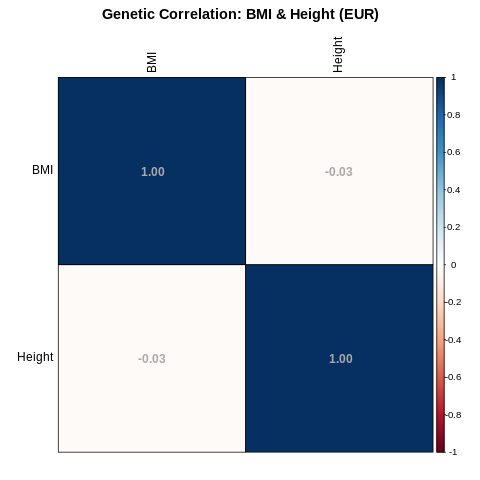

In [12]:
%%R
rownames(LDSC_EUR$S) <- colnames(LDSC_EUR$S)

corrplot(
  corr = cov2cor(LDSC_EUR$S),
  method = "color",
  addCoef.col = "dark grey",
  add = FALSE,
  bg = "white",
  diag = TRUE,
  outline = TRUE,
  tl.col = "black",
  mar = c(1,1,2,1),
  title = "Genetic Correlation: BMI & Height (EUR)"
)


---
## 🌏 Part 2: Continuous Traits Example in East Asian Ancestry

The summary statistics and LD scores for this section are from East Asian (EAS) ancestry. We will perform similar bivariate LDSC analyses for BMI and Height.

As before, we start by examining if the sumstats files have the necessary columns.


In [13]:
%%R
# Look at the files
preview_text(file.path(eas_dir, "BMI_EAS_chr1.txt"))
preview_text(file.path(eas_dir, "Yengo_Height_EAS_chr1.txt"))


--- Preview of BMI_EAS_chr1.txt ---
SNP CHR BP ALLELE1 ALLELE0 INFO MAF BETA SE PVAL
rs28544273 1 751343 T A 0.902227 0.148008 0.000594251 0.00468681 0.9
rs28527770 1 751756 T C 0.907138 0.147545 0.000570884 0.00467584 0.9
rs3094315 1 752566 G A 0.99888 0.157581 -0.000588948 0.00433112 0.89
rs3131971 1 752894 T C 0.935874 0.150678 -0.000526474 0.00455903 0.91

--- Preview of Yengo_Height_EAS_chr1.txt ---
RSID CHR POS EFFECT_ALLELE OTHER_ALLELE EFFECT_ALLELE_FREQ BETA SE P N MAF
rs3131972 1 752721 G A 0.833 0.00210069 0.00438 0.63153 239087 0.167
rs3131969 1 754182 G A 0.829 0.00287384 0.0048 0.549178 239087 0.171
rs3131967 1 754334 C T 0.833 0.00220745 0.00479 0.645187 239086 0.167
rs1048488 1 760912 T C 0.855 0.000498632 0.00453 0.912282 257029 0.145



### ❓ Question 7: Identifying Columns
* Is the sample size ($N$) column present for both?
* Which column is the effect allele (A1) for each trait?

<details>
<summary>💡 Click here to reveal the answers!</summary>

* **Sample Size (N):** The BMI sumstats *do not* include N! So, we have to manually specify `N` for BMI when we run `munge()`.
* **Effect Allele (A1):** The effect allele is `ALLELE1` in the BMI sumstats and `EFFECT_ALLELE` in the Height sumstats.
</details>


In [15]:
%%R
hm3_eas <- file.path(eas_dir, "eas_ldscores", "w_hm3.snplist")
preview_text(hm3_eas)
cat("Number of lines in EAS HM3 file:", count_lines(hm3_eas), "\n")

files_eas <- c(
  file.path(eas_dir, "BMI_EAS_chr1.txt"),
  file.path(eas_dir, "Yengo_Height_EAS_chr1.txt")
)

names_eas <- c("BMI_EAS_chr1", "Height_EAS_chr1")

# Note that we are using ancestrally matched LD scores!
# We also provide a vector for N. The first is for BMI (since it was missing),
# and the second is NA because Height already has an N column.
munge(
  files = files_eas,
  hm3 = hm3_eas,
  trait.names = names_eas,
  N = c(163835, NA),
  info.filter = 0.9,
  maf.filter = 0.01
)


--- Preview of w_hm3.snplist ---
SNP	A1	A2
rs3094315	G	A
rs3131972	A	G
rs3131969	A	G
rs1048488	C	T

Number of lines in EAS HM3 file: 1217312 
The munging of 2 summary statistics started at 2026-06-25 11:36:21.502562
Reading in reference file
Reading summary statistics for /content/LDSC_Practical_2/final/EAS/BMI_EAS_chr1.txt /content/LDSC_Practical_2/final/EAS/Yengo_Height_EAS_chr1.txt. Please note that this step usually takes a few minutes due to the size of summary statistic files.
All files loaded into R!
Munging file: /content/LDSC_Practical_2/final/EAS/BMI_EAS_chr1.txt
Interpreting the SNP column as the SNP column.
Interpreting the ALLELE1 column as the A1 column.
Interpreting the ALLELE0 column as the A2 column.
Interpreting the BETA column as the effect column.
Interpreting the INFO column as the INFO column.
Interpreting the PVAL column as the P column.
Interpreting the MAF column as the MAF column.
Interpreting the SE column as the SE column.
Using provided N (163835) for file:

Now, we can run LDSC analyses as before.


In [16]:
%%R
preview_gz(file.path(eas_dir, "BMI.sumstats.gz"))
preview_gz(file.path(eas_dir, "Height.sumstats.gz"))

traits_eas <- c(
  file.path(eas_dir, "BMI.sumstats.gz"),
  file.path(eas_dir, "Height.sumstats.gz")
)

sample_prev_eas     <- c(NA, NA)
population_prev_eas <- c(NA, NA)

LDSC_EAS <- ldsc(
  traits = traits_eas,
  sample.prev = sample_prev_eas,
  population.prev = population_prev_eas,
  ld = file.path(eas_dir, "eas_ldscores"),
  wld = file.path(eas_dir, "eas_ldscores"),
  trait.names = c("BMI", "Height")
)


--- Preview of BMI.sumstats.gz ---
SNP	N	Z	A1	A2
rs1000050	163835	-1.91103564754912	C	T
rs1000073	163835	0.495850347347453	A	G
rs1000283	163835	1.64485362695147	A	G
rs1000313	163835	0.48172684958473	G	A

--- Preview of Height.sumstats.gz ---
SNP	N	Z	A1	A2
rs1000050	264725	3.69067358263067	C	T
rs1000073	264725	-1.05010900285593	A	G
rs1000283	264725	3.43118437494083	A	G
rs1000313	264725	1.29587950855942	G	A

Multivariate ld-score regression of 2 traits (/content/LDSC_Practical_2/final/EAS/BMI.sumstats.gz /content/LDSC_Practical_2/final/EAS/Height.sumstats.gz) began at: 2026-06-25 11:36:53.124699
Reading in LD scores
Read in summary statistics [1/2] from: /content/LDSC_Practical_2/final/EAS/BMI.sumstats.gz
Out of 78523 SNPs, 78478 remain after merging with LD-score files
Removing 0 SNPs with Chi^2 > 163.835; 78478 remain
Read in summary statistics [2/2] from: /content/LDSC_Practical_2/final/EAS/Height.sumstats.gz
Out of 80124 SNPs, 79643 remain after merging with LD-score files
Removing 3

### ❓ Question 8: Comparing Heritabilities
How do the $h^2_{\text{SNP}}$ estimates for BMI and Height in East Asians compare to the European estimates from Part 1?

<details>
<summary>💡 Click here to reveal the answer!</summary>

The $h^2_{\text{SNP}}$ estimates of both BMI and Height are lower in the East Asian ancestry sample than the European ancestry sample:
* **BMI:** `0.14` in EAS vs `0.21` in EUR
* **Height:** `0.24` in EAS vs `0.42` in EUR

*We might discuss later why there is a difference! (Hint: differences in sample size, imputation quality, LD reference panels, or true genetic architecture).*
</details>


### ❓ Question 9: EAS Genetic Correlation
What is the genetic correlation between BMI and Height in the EAS ancestry sample?

<details>
<summary>💡 Click here to reveal the answer!</summary>

The genetic correlation between BMI and height in the EAS ancestry sample is **`-0.129`** (SE = `0.077`).
</details>


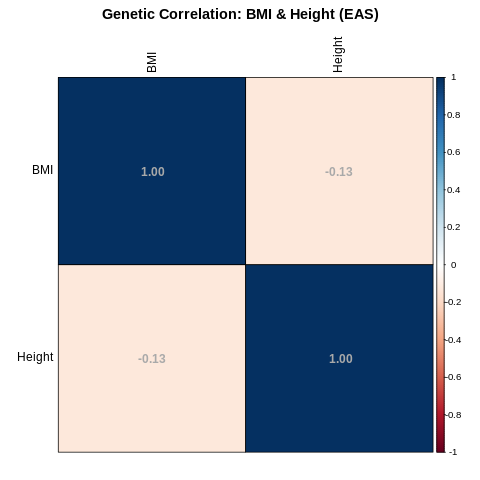

In [17]:
%%R
rownames(LDSC_EAS$S) <- colnames(LDSC_EAS$S)

corrplot(
  corr = cov2cor(LDSC_EAS$S),
  method = "color",
  addCoef.col = "dark grey",
  add = FALSE,
  bg = "white",
  diag = TRUE,
  outline = TRUE,
  tl.col = "black",
  mar = c(1,1,2,1),
  title = "Genetic Correlation: BMI & Height (EAS)"
)


---
## 🧠 Part 3: Binary (Case/Control) Traits Example in European Ancestry

Now, we will perform bivariate LDSC analyses for two psychiatric disorders: **Schizophrenia (SCZ)** and **Bipolar Disorder (BIP)** in European ancestry.

As before, we will first examine the columns in the GWAS sumstats file.


In [18]:
%%R
# Files
preview_text(file.path(eur_dir, "SCZ_chr1.txt"))
preview_text(file.path(eur_dir, "BIP_chr1.txt"))


--- Preview of SCZ_chr1.txt ---
"CHROM" "ID" "POS" "A1" "A2" "FCAS" "FCON" "IMPINFO" "BETA" "SE" "PVAL" "NCAS" "NCON" "NEFF"
"229952" 1 "rs12034030" 68677760 "C" "T" 0.824 0.824 0.983 0.0021975835434872 0.0114 0.8488 53386 77258 117498.26
"229953" 1 "rs114605216" 69228887 "T" "C" 0.957 0.957 0.831 -0.0166986496230515 0.0233 0.4726 53386 77258 117498.26
"229954" 1 "rs10889564" 66053488 "C" "A" 0.721 0.72 0.996 -0.00950503001430495 0.0096 0.3246 53386 77258 117498.26
"229955" 1 "rs56235896" 61957893 "G" "T" 0.954 0.956 0.873 -0.0231969816042026 0.0224 0.3007 53386 77258 117498.26

--- Preview of BIP_chr1.txt ---
"CHR" "POS" "ID" "A1" "A2" "BETA" "SE" "PVAL" "NGT" "FCAS" "FCON" "IMPINFO" "NEFFDIV2" "NCAS" "NCON" "DIRE"
"108848" 1 208917922 "rs11119125" "C" "T" -0.0329985112635755 0.0323 0.3077 1 0.976 0.98 0.928 49016.76 40159 368309 "+?-+--??-+++++++-++-++--?-++--+?+--?+++++-++++--+---??+??"
"108849" 1 207014776 "rs960326" "C" "T" -0.00150112612626709 0.0162 0.9256 7 0.0893 0.101 0.996 5

### ❓ Question 10: Effective Sample Size
How are the sample sizes reported in the SCZ and BIP summary statistics?

<details>
<summary>💡 Click here to reveal the answer!</summary>

* SCZ sumstats include the effective $N$ (`NEFF`).
* BIP sumstats include `NEFFDIV2`, which is half of the effective $N$.

Note that `munge()` can usually recognize these different types of $N$ and interpret them properly!
</details>


In [19]:
%%R
files_bin <- c(
  file.path(eur_dir, "SCZ_chr1.txt"),
  file.path(eur_dir, "BIP_chr1.txt")
)

names_bin <- c("SCZ","BIP")

munge(
  files = files_bin,
  hm3 = hm3_eur,
  trait.names = names_bin,
  info.filter = 0.9,
  maf.filter = 0.01
)


The munging of 2 summary statistics started at 2026-06-25 11:39:40.003477
Reading in reference file
Reading summary statistics for /content/LDSC_Practical_2/final/EUR/SCZ_chr1.txt /content/LDSC_Practical_2/final/EUR/BIP_chr1.txt. Please note that this step usually takes a few minutes due to the size of summary statistic files.
All files loaded into R!
Munging file: /content/LDSC_Practical_2/final/EUR/SCZ_chr1.txt
Found an NEFF column for sample size. 

Please note that this is likely effective sample size and should only be used for liability h^2 conversion for binary traits and that it should reflect the sum of effective sample sizes across cohorts.

Be aware that some NEFF columns reflect half of the effective sample size; the function will automatically double the column names if recognized [check above in .log file to determine if this is the case].
If the Neff value is halved in the summary stats, but not recognized by the munge function, this should be manually doubled prior to r

### ❓ Question 11: Munge $N$ interpretation
Look at the munge log. How was $N$ calculated for the BIP sumstats?

<details>
<summary>💡 Click here to reveal the answer!</summary>

For BIP, $N_{\text{eff}}$ is calculated by doubling `NEFFDIV2`.
If `munge()` does not identify the column correctly or doesn't double `NEFFDIV2`, you would need to manually create a new column (`NEFF = 2 * NEFFDIV2`) in the raw dataset before running `munge()`.
</details>


Note that we need to specify the sample prevalence and population prevalence to obtain liability-scale estimates for binary traits.

The population prevalences of SCZ and BIP (0.01 and 0.02, respectively) are obtained from published epidemiological studies.

### ❓ Question 12: Sample prevalence for effective $N$
What is the "sample prevalence" when we use the effective $N$ (rather than the actual $N$, which is the sum of $N_{\text{cases}}$ and $N_{\text{controls}}$)?

<details>
<summary>💡 Click here to reveal the answer!</summary>
Effective $N$ implies sample prevalence = 0.5.
</details>

Now, we run `ldsc()`.
LDSC will first report the **observed-scale** estimates, then the **liability-scale** estimates.


In [20]:
%%R
preview_gz(file.path(eur_dir, "SCZ.sumstats.gz"))
preview_gz(file.path(eur_dir, "BIP.sumstats.gz"))

traits_bin <- c(
  file.path(eur_dir, "SCZ.sumstats.gz"),
  file.path(eur_dir, "BIP.sumstats.gz")
)

# For binary traits we must specify sample and population prevalence!
# Because the sumstats use Effective N, we set sample.prev = 0.5 (meaning 50% cases / 50% controls)
sample_prev_bin     <- c(0.5, 0.5)
population_prev_bin <- c(0.01, 0.02) # SCZ ~ 1%, BIP ~ 2%

LDSC_SCZ_BIP <- ldsc(
  traits = traits_bin,
  sample.prev = sample_prev_bin,
  population.prev = population_prev_bin,
  ld = file.path(eur_dir, "eur_w_ld_chr"),
  wld = file.path(eur_dir, "eur_w_ld_chr"),
  trait.names = c("SCZ", "BIP")
)


--- Preview of SCZ.sumstats.gz ---
SNP	N	Z	A1	A2
rs1000050	117498.26	0.144127233511731	C	T
rs1000073	117498.26	-0.194735524167608	A	G
rs1000283	117498.26	-0.504514322598141	A	G
rs1000313	117498.26	1.19624747320143	G	A

--- Preview of BIP.sumstats.gz ---
SNP	N	Z	A1	A2
rs1000050	101962.96	-1.08912220295691	C	T
rs1000073	101962.96	-1.22413845894589	A	G
rs1000283	101962.96	-3.31146152952416	A	G
rs1000313	101962.96	-0.693333953293917	G	A

Multivariate ld-score regression of 2 traits (/content/LDSC_Practical_2/final/EUR/SCZ.sumstats.gz /content/LDSC_Practical_2/final/EUR/BIP.sumstats.gz) began at: 2026-06-25 11:41:40.429195
Reading in LD scores
Read in summary statistics [1/2] from: /content/LDSC_Practical_2/final/EUR/SCZ.sumstats.gz
Out of 93561 SNPs, 93295 remain after merging with LD-score files
Removing 0 SNPs with Chi^2 > 117.49826; 93295 remain
Read in summary statistics [2/2] from: /content/LDSC_Practical_2/final/EUR/BIP.sumstats.gz
Out of 92758 SNPs, 92535 remain after merging with L

### ❓ Question 13: Intercepts and Inflation
What are the univariate LDSC intercepts for SCZ and BIP? Do they suggest bias?

<details>
<summary>💡 Click here to reveal the answer!</summary>

* **SCZ:** LDSC intercept = 1.1072 (SE = 0.0523). Attenuation Ratio = 0.0896 (SE = 0.0437)
* **BIP:** LDSC intercept = 1.0032 (SE = 0.0349). Attenuation Ratio = 0.005 (SE = 0.055)

Though SCZ suggests a small amount of bias (~8% of the inflation is not due to polygenicity), the vast majority of the signal for both traits is highly polygenic.
</details>


### ❓ Question 14: Shared Confounding
What is the cross-trait LDSC intercept? What does this mean?

<details>
<summary>💡 Click here to reveal the answer!</summary>

Cross-trait LDSC intercept = 0.1945 (SE = 0.0315).

Since this is significantly greater than 0, it suggests likely **sample overlap** (e.g., the same controls were used for both the SCZ and BIP GWAS).
There could also be some shared residual population stratification.

Note that the genetic covariance and correlation are estimated after accounting for these factors (sample overlap or shared confounding).
</details>


### ❓ Question 15: Genetic Correlation
What are the genetic covariance and genetic correlation between SCZ and BIP?

<details>
<summary>💡 Click here to reveal the answer!</summary>

* **Genetic covariance (liability-scale)** = 0.1511 (SE = 0.0168)
* **Genetic correlation ($r_g$)** = 0.7276 (SE = 0.0809)

This is a massive genetic correlation, indicating strong shared genetic architecture between Schizophrenia and Bipolar Disorder!
</details>


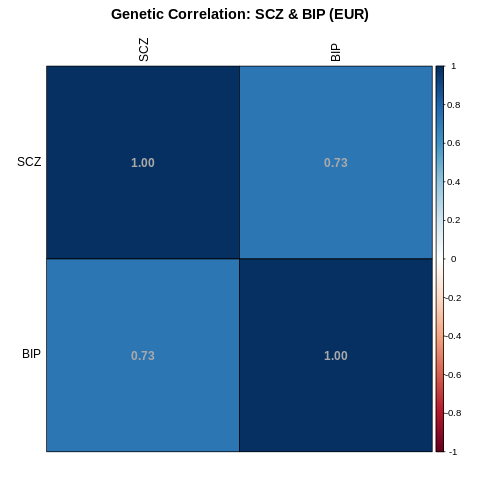

In [21]:
%%R
rownames(LDSC_SCZ_BIP$S) <- colnames(LDSC_SCZ_BIP$S)

corrplot(
  corr = cov2cor(LDSC_SCZ_BIP$S),
  method = "color",
  addCoef.col = "dark grey",
  add = FALSE,
  bg = "white",
  diag = TRUE,
  outline = TRUE,
  tl.col = "black",
  mar = c(1,1,2,1),
  title = "Genetic Correlation: SCZ & BIP (EUR)"
)


---
## 🧗 Open-ended challenges

You've estimated $r_g$ end to end. These last questions have **no single right answer** — they're for thinking about what $r_g$ does and doesn't tell you. Discuss with your neighbour, and peek at the hints when you're ready.


### ❓ Question 16: Does a high $r_g$ mean one trait *causes* the other?

We found a large genetic correlation between Schizophrenia and Bipolar Disorder. Can we conclude that one disorder causes the other? Why or why not?

<details>
<summary>💡 Click here to reveal the answer!</summary>

**No.** A genetic correlation is symmetric — $r_g(A,B) = r_g(B,A)$ — so it carries no direction and cannot by itself establish causation. A high $r_g$ is consistent with several very different scenarios:

* **Shared genetics (pleiotropy):** the same variants influence both traits directly.
* **Causal chain:** trait A genetically influences trait B (or vice versa) — and $r_g$ alone can't tell you which.
* **Reverse causation / confounding:** a third factor (or a mis-specified phenotype) drives both.

To probe *causality* and its direction you need a different tool — e.g. **Mendelian randomisation**, which uses genetic variants as instruments. $r_g$ tells you *that* two traits share genetic architecture, not *why*.
</details>


### ❓ Question 17: Why can low-heritability traits give unstable $r_g$ (even $|r_g| > 1$)?

Recall that $r_g = \dfrac{\rho_g}{\sqrt{h^2_1 \, h^2_2}}$. What happens to this estimate when one or both traits have very low (and noisily estimated) SNP heritability?

<details>
<summary>💡 Click here to reveal the answer!</summary>

$r_g$ divides the genetic covariance by $\sqrt{h^2_1 h^2_2}$. When a trait's $h^2$ is small and imprecisely estimated, that **denominator is tiny and noisy**, so the ratio becomes unstable and its standard error blows up — sometimes pushing the point estimate **outside the valid $[-1, 1]$ range**.

A common **rule of thumb**: ignore $r_g$ when a trait's $h^2$ $Z$-score is below ~4 (i.e. $h^2$ is not at least ~4 SEs from zero). This is also why the lower-powered EAS analysis earlier gives noisier estimates than EUR.

*Coding extension:* you've already built the genetic covariance matrix with `cov2cor()`. Pull the covariance and the two heritabilities out of `$S` and verify by hand that $r_g = \rho_g / \sqrt{h^2_1 h^2_2}$.
</details>


### ❓ Question 18: Could we estimate $r_g$ between a trait in EUR and the *same* trait in EAS?

Throughout this practical we were careful to use **ancestry-matched LD scores**. Why can't standard LDSC estimate a genetic correlation *across* ancestries (e.g. height in Europeans vs height in East Asians)?

<details>
<summary>💡 Click here to reveal the answer!</summary>

LDSC's regression links a SNP's statistic to its **LD score** — how much LD it tags. But **LD patterns differ between ancestries** (different haplotype structure and allele frequencies), so one set of LD scores can't describe two populations at once, and the cross-population correlation of *causal* effects isn't what bivariate LDSC estimates.

Estimating a **cross-ancestry genetic correlation** (trans-ethnic $r_g$) needs purpose-built methods that model both populations' LD — e.g. **Popcorn** and **S-LDXR**.
</details>


### ❓ Question 19: A genome-wide $r_g \approx 0$ — does that mean *no* shared genetics anywhere?

Two traits come back with a genome-wide genetic correlation indistinguishable from zero. Is it safe to conclude they share no genetics at all?

<details>
<summary>💡 Click here to reveal the answer!</summary>

**Not necessarily.** Genome-wide $r_g$ is an *average* over the whole genome. Some regions can be **positively** correlated while others are **negatively** correlated, and these opposing local correlations can **cancel** to give a genome-wide $r_g \approx 0$ — masking real, biologically interesting local sharing.

To look *regionally* you need **local** genetic-correlation methods such as **LAVA** and **SUPERGNOVA**, which estimate $r_g$ within genomic windows rather than genome-wide.
</details>


### ❓ Question 20: Could $r_g$ be inflated by something other than shared biology?

Imagine people tend to partner with others who are similar for *two different* traits (say, height and educational attainment). How might this **assortative mating** affect an estimated genetic correlation between those traits?

<details>
<summary>💡 Click here to reveal the answer!</summary>

**Assortative mating** — non-random partner choice — can build up statistical associations between trait-influencing alleles across the genome, *even between loci that are biologically unrelated*. Cross-trait assortment can therefore **induce or inflate** a genetic correlation that doesn't reflect shared molecular biology. It's a reminder that $r_g$ reflects the *population's* genetic structure, which is shaped by demography and mating patterns — not pleiotropy alone.
</details>


### ❓ Question 21: Which of *your own* estimates would you trust most — and least?

Look back at the three analyses you ran: BMI–Height in EUR, BMI–Height in EAS, and SCZ–BIP in EUR. Using everything above, which $r_g$ estimate would you trust most, and which least? What would you check?

<details>
<summary>💡 Click here to reveal the answer!</summary>

No single right answer, but good reasoning weighs:

* **Heritability and its precision** — higher, well-estimated $h^2$ (large $h^2$ $Z$-score) ⇒ a more stable $r_g$. The EAS analysis had **lower $h^2$** and smaller samples than EUR, so its $r_g$ is noisier.
* **Standard errors** — compare the SE of each $r_g$; SCZ–BIP gave a large, precisely-estimated $r_g$.
* **The cross-trait intercept** — a non-zero intercept flags sample overlap / shared confounding; reassuringly $r_g$ is estimated *after* accounting for it (overlap lands in the intercept, not the slope).

A reasonable take: **SCZ–BIP** is the most trustworthy (large, precise $r_g$ from heritable traits), while **EAS BMI–Height** deserves the most caution (lower power and $h^2$).
</details>


---
## 🏁 End of Practical 2

You have now completed Practical 2 for estimating Genetic Correlation using LDSC!
